## Lake Zug Retreat Day 2

In [233]:
# imports
import ewgreaders as ewg
import xarray as xr
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os

In [250]:
def load_thermistor_chain(di):
    all_temp = []
    for _, row in di.iterrows():
        mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
        deploy, retrieve = mreader.get_deploy_retrieve_dates()
        t_start = deploy + pd.Timedelta(days=1)
        t_end = retrieve - pd.Timedelta(days=1)
        treader = ewg.thermistor_reader.ThermistorReader(row.lake, row.date, row.location, row.serial_id)
        ds = treader.load().sel(time=slice(t_start, t_end))
        all_temp.append(ds)

    ds_temp = mreader.create_instrument_chain(all_temp)

    return ds_temp

def hr_to_hz(period):
    return 1 / (period * 3600)

def temp_welch(ds_temp, d, loc, lbl, sfreq=1/10):
    # select depth
    temp = ds_temp.sel(depth=d, method='nearest')
    depth = temp.depth.item()

    # detrend
    temp = scipy.signal.detrend(temp, type='linear')

    # spectral decomposition
    freqs, psd = scipy.signal.welch(temp, fs=sfreq, nperseg=25920)    # 72-hour segment

    data = pd.DataFrame({
        'freq': freqs[1:],
        'period': (1/freqs[1:]) / 3600,
        'power': psd[1:]
    })
    data['depth'] = depth
    data['loc'] = loc
    data['label'] = lbl

    return data

def rolling_average_circular(da, window):
    da_rad = np.deg2rad(da)

    sin = np.sin(da_rad)
    cos = np.cos(da_rad)

    sin_ra = sin.rolling(time=window, center=True).mean()
    cos_ra = cos.rolling(time=window, center=True).mean()

    da_rad_ra = np.arctan2(sin_ra, cos_ra)

    da_ra = np.rad2deg(da_rad_ra)

    return da_ra % 360

In [3]:
lake = 'Zug'

di_m = ewg.get_data_index(lake, 'mooring')

### Temperature Spectra

In [276]:
t_start = pd.to_datetime('2026-02-05') + pd.Timedelta(days=1)
t_end = pd.to_datetime('2026-04-09') - pd.Timedelta(days=1)

In [295]:
all_ds = []
for year in ['2025', '2026']:
    meteo_path = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Meteo/meteo_cham.nc'
    ds = xr.open_dataset(meteo_path)
    all_ds.append(ds)

ds_meteo = xr.concat(all_ds, dim='time')
ds_meteo = ds_meteo.sel(time=slice(t_start, t_end))

# wind speed, 1-day rolling average
wind_speed = ds_meteo['wind_speed']
wind_speed_ra = wind_speed.rolling(time=6*24, center=True).mean()

# wind direction, 1-day rolling average, u/v projections
wind_dir = ds_meteo['wind_direction']
wind_dir_ra = rolling_average_circular(wind_dir, 6*24)
wind_dir_rad = np.deg2rad(wind_dir_ra)
u_wind_ra = -wind_speed_ra * np.sin(wind_dir_rad)
v_wind_ra = -wind_speed_ra * np.cos(wind_dir_rad)

In [6]:
date = '2026-04-09'
sensor = ['rbr_temp', 'rbr_duet']
di_m_sel = di_m.query("date == @date and sensor in @sensor")

C:\Users\herremha\AppData\Local\Temp\ipykernel_18792\472603837.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and sensor in @sensor")


In [ ]:
di_m_w = di_m_sel.query("location == 'LZW'")
ds_temp_w = load_thermistor_chain(di_m_w).temp

di_m_c = di_m_sel.query("location == 'LZC'")
ds_temp_c = load_thermistor_chain(di_m_c).temp

di_m_e = di_m_sel.query("location == 'LZE'")
ds_temp_e = load_thermistor_chain(di_m_e).temp

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:229: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:229: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_alig

In [189]:
t0 = pd.to_datetime('2026-03-17 12:00:00')
tf = pd.to_datetime('2026-03-19 12:00:00')

t0_prime = t0 - pd.Timedelta(days=5)
tf_prime = tf + pd.Timedelta(days=5)

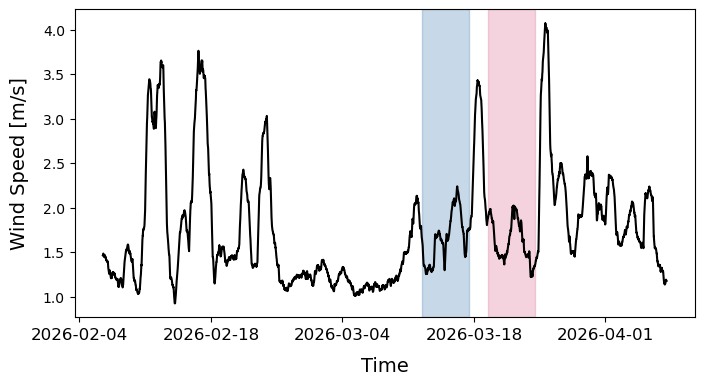

In [190]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.axvspan(t0_prime, t0, color='steelblue', alpha=0.3)
ax.axvspan(tf, tf_prime, color='palevioletred', alpha=0.3)
sns.lineplot(x=wind_speed_ra.time, y=wind_speed_ra, color='black', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Wind Speed [m/s]', fontsize=14, labelpad=10)
ax.tick_params(axis='x', labelsize=12)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))

plt.show()

In [191]:
temp_w_prior = ds_temp_w.sel(time=slice(t0_prime, t0))
temp_w_after = ds_temp_w.sel(time=slice(tf, tf_prime))

temp_c_prior = ds_temp_c.sel(time=slice(t0_prime, t0))
temp_c_after = ds_temp_c.sel(time=slice(tf, tf_prime))

temp_e_prior = ds_temp_e.sel(time=slice(t0_prime, t0))
temp_e_after = ds_temp_e.sel(time=slice(tf, tf_prime))

In [192]:
d = 125
psd_wp = temp_welch(temp_w_prior, d, 'W', 'prior')
psd_wa = temp_welch(temp_w_after, d, 'W', 'after')
psd_cp = temp_welch(temp_c_prior, d, 'C', 'prior')
psd_ca = temp_welch(temp_c_after, d, 'C', 'after')
psd_ep = temp_welch(temp_e_prior, d, 'E', 'prior')
psd_ea = temp_welch(temp_e_after, d, 'E', 'after')

df_psd = pd.concat([psd_wp, psd_wa, psd_cp, psd_ca, psd_ep, psd_ea], ignore_index=True)
df_psd = df_psd[df_psd['period'] > 0.5]
depth_w = df_psd.query("loc == 'W'").depth.unique()[0]
depth_c = df_psd.query("loc == 'C'").depth.unique()[0]
depth_e = df_psd.query("loc == 'E'").depth.unique()[0]

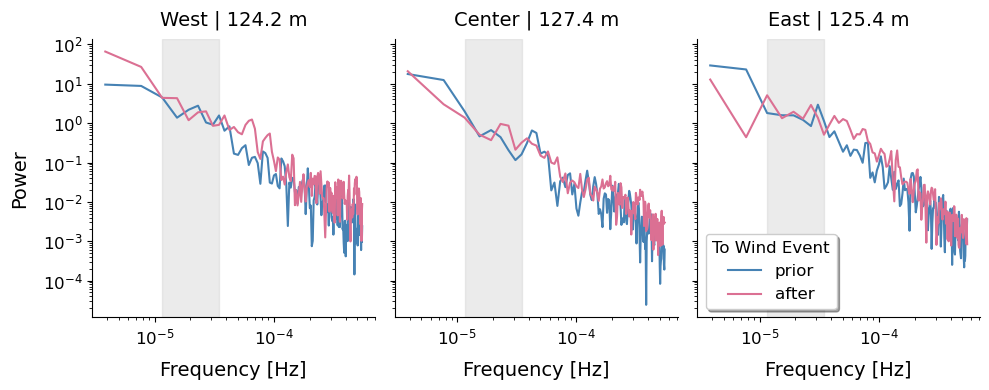

In [193]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharey=True, sharex=True)
order = ['prior', 'after']
palette = ['steelblue', 'palevioletred']

# LZW
ax[0].axvspan(hr_to_hz(24), hr_to_hz(8), color='silver', alpha=0.3)
sns.lineplot(df_psd.query("loc == 'W'"), x='freq', y='power', hue='label', hue_order=order, palette=palette, ax=ax[0], legend=False)

# LZC
ax[1].axvspan(hr_to_hz(24), hr_to_hz(8), color='silver', alpha=0.3)
sns.lineplot(df_psd.query("loc == 'C'"), x='freq', y='power', hue='label', hue_order=order, palette=palette, ax=ax[1], legend=False)

# LZE
ax[2].axvspan(hr_to_hz(24), hr_to_hz(8), color='silver', alpha=0.3)
sns.lineplot(df_psd.query("loc == 'E'"), x='freq', y='power', hue='label', hue_order=order, palette=palette, ax=ax[2])

ax[0].set_ylabel('Power', fontsize=14, labelpad=10)
ax[0].set_title(f'West | {depth_w} m', fontsize=14, pad=10)
ax[1].set_title(f'Center | {depth_c} m', fontsize=14, pad=10)
ax[2].set_title(f'East | {depth_e} m', fontsize=14, pad=10)

for i in range(len(ax)):
    ax[i].set_xlabel('Frequency [Hz]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')

ax[2].legend(title='To Wind Event', fontsize=12, title_fontsize=12, ncols=1, shadow=True, loc='lower left')

plt.tight_layout()
plt.show()

In [194]:
d = 105
psd_wp = temp_welch(temp_w_prior, d, 'W', 'prior')
psd_wa = temp_welch(temp_w_after, d, 'W', 'after')
psd_cp = temp_welch(temp_c_prior, d, 'C', 'prior')
psd_ca = temp_welch(temp_c_after, d, 'C', 'after')
psd_ep = temp_welch(temp_e_prior, d, 'E', 'prior')
psd_ea = temp_welch(temp_e_after, d, 'E', 'after')

df_psd = pd.concat([psd_wp, psd_wa, psd_cp, psd_ca, psd_ep, psd_ea], ignore_index=True)
df_psd = df_psd[df_psd['period'] > 0.5]
depth_w = df_psd.query("loc == 'W'").depth.unique()[0]
depth_c = df_psd.query("loc == 'C'").depth.unique()[0]
depth_e = df_psd.query("loc == 'E'").depth.unique()[0]

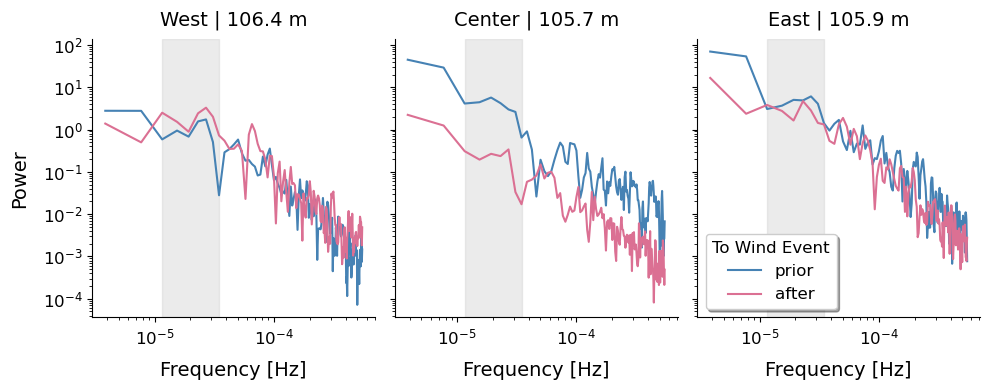

In [195]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharey=True, sharex=True)
order = ['prior', 'after']
palette = ['steelblue', 'palevioletred']

# LZW
ax[0].axvspan(hr_to_hz(24), hr_to_hz(8), color='silver', alpha=0.3)
sns.lineplot(df_psd.query("loc == 'W'"), x='freq', y='power', hue='label', hue_order=order, palette=palette, ax=ax[0], legend=False)

# LZC
ax[1].axvspan(hr_to_hz(24), hr_to_hz(8), color='silver', alpha=0.3)
sns.lineplot(df_psd.query("loc == 'C'"), x='freq', y='power', hue='label', hue_order=order, palette=palette, ax=ax[1], legend=False)

# LZE
ax[2].axvspan(hr_to_hz(24), hr_to_hz(8), color='silver', alpha=0.3)
sns.lineplot(df_psd.query("loc == 'E'"), x='freq', y='power', hue='label', hue_order=order, palette=palette, ax=ax[2])

ax[0].set_ylabel('Power', fontsize=14, labelpad=10)
ax[0].set_title(f'West | {depth_w} m', fontsize=14, pad=10)
ax[1].set_title(f'Center | {depth_c} m', fontsize=14, pad=10)
ax[2].set_title(f'East | {depth_e} m', fontsize=14, pad=10)

for i in range(len(ax)):
    ax[i].set_xlabel('Frequency [Hz]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')

ax[2].legend(title='To Wind Event', fontsize=12, title_fontsize=12, ncols=1, shadow=True, loc='lower left')

plt.tight_layout()
plt.show()

In [196]:
t0 = pd.to_datetime('2026-03-10')
tf = pd.to_datetime('2026-02-18')

t0_prime = t0 - pd.Timedelta(days=5)
tf_prime = tf + pd.Timedelta(days=5)

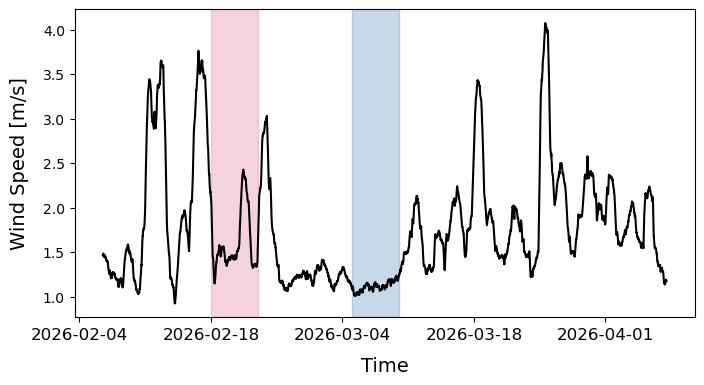

In [197]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.axvspan(t0_prime, t0, color='steelblue', alpha=0.3)
ax.axvspan(tf, tf_prime, color='palevioletred', alpha=0.3)
sns.lineplot(x=wind_speed_ra.time, y=wind_speed_ra, color='black', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Wind Speed [m/s]', fontsize=14, labelpad=10)
ax.tick_params(axis='x', labelsize=12)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))

plt.show()

In [205]:
temp_w_prior = ds_temp_w.sel(time=slice(t0_prime, t0))
temp_w_after = ds_temp_w.sel(time=slice(tf, tf_prime))

temp_c_prior = ds_temp_c.sel(time=slice(t0_prime, t0))
temp_c_after = ds_temp_c.sel(time=slice(tf, tf_prime))

temp_e_prior = ds_temp_e.sel(time=slice(t0_prime, t0))
temp_e_after = ds_temp_e.sel(time=slice(tf, tf_prime))

In [214]:
d = 125
psd_wp = temp_welch(temp_w_prior, d, 'W', 'prior')
psd_wa = temp_welch(temp_w_after, d, 'W', 'after')
psd_cp = temp_welch(temp_c_prior, d, 'C', 'prior')
psd_ca = temp_welch(temp_c_after, d, 'C', 'after')
psd_ep = temp_welch(temp_e_prior, d, 'E', 'prior')
psd_ea = temp_welch(temp_e_after, d, 'E', 'after')

df_psd = pd.concat([psd_wp, psd_wa, psd_cp, psd_ca, psd_ep, psd_ea], ignore_index=True)
df_psd = df_psd[df_psd['period'] > 0.5]
depth_w = df_psd.query("loc == 'W'").depth.unique()[0]
depth_c = df_psd.query("loc == 'C'").depth.unique()[0]
depth_e = df_psd.query("loc == 'E'").depth.unique()[0]

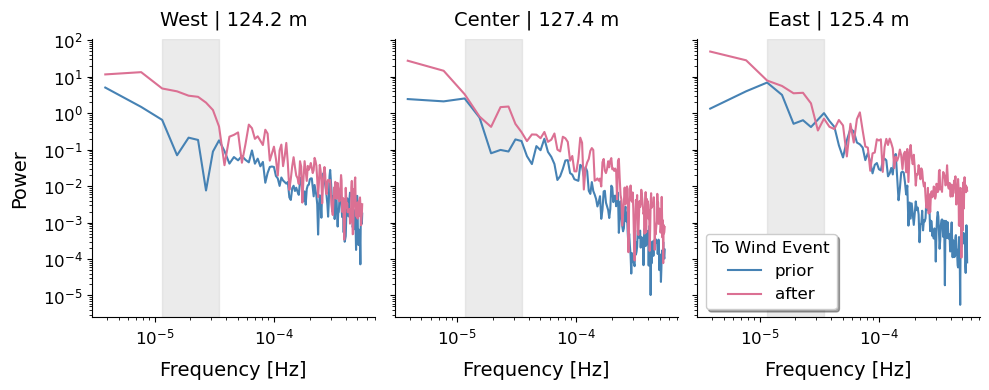

In [215]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharey=True, sharex=True)
order = ['prior', 'after']
palette = ['steelblue', 'palevioletred']

# LZW
ax[0].axvspan(hr_to_hz(24), hr_to_hz(8), color='silver', alpha=0.3)
sns.lineplot(df_psd.query("loc == 'W'"), x='freq', y='power', hue='label', hue_order=order, palette=palette, ax=ax[0], legend=False)

# LZC
ax[1].axvspan(hr_to_hz(24), hr_to_hz(8), color='silver', alpha=0.3)
sns.lineplot(df_psd.query("loc == 'C'"), x='freq', y='power', hue='label', hue_order=order, palette=palette, ax=ax[1], legend=False)

# LZE
ax[2].axvspan(hr_to_hz(24), hr_to_hz(8), color='silver', alpha=0.3)
sns.lineplot(df_psd.query("loc == 'E'"), x='freq', y='power', hue='label', hue_order=order, palette=palette, ax=ax[2])

ax[0].set_ylabel('Power', fontsize=14, labelpad=10)
ax[0].set_title(f'West | {depth_w} m', fontsize=14, pad=10)
ax[1].set_title(f'Center | {depth_c} m', fontsize=14, pad=10)
ax[2].set_title(f'East | {depth_e} m', fontsize=14, pad=10)

for i in range(len(ax)):
    ax[i].set_xlabel('Frequency [Hz]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')

ax[2].legend(title='To Wind Event', fontsize=12, title_fontsize=12, ncols=1, shadow=True, loc='lower left')

plt.tight_layout()
plt.show()

### Wind and flow surges

In [284]:
date = pd.to_datetime('2026-04-09')
loc_w = 'LZW'
sid_w = '16576'
loc_c = 'LZC'
sid_c = '16549'
loc_e = 'LZE'
sid_e = '23656'

In [285]:
areader = ewg.adcp_reader.ADCPReader(lake, date, loc_w, sid_w)
ds_w = areader.load()

areader = ewg.adcp_reader.ADCPReader(lake, date, loc_c, sid_c)
ds_c = areader.load()

areader = ewg.adcp_reader.ADCPReader(lake, date, loc_e, sid_e)
ds_e = areader.load()

In [286]:
deploy = pd.to_datetime('2026-02-05')
retrieve = pd.to_datetime('2026-04-09')
t_start = deploy + pd.Timedelta(days=1)
#t_end = retrieve - pd.Timedelta(days=1)
t_end = ds_e.time.values[-1]

z_max = 130
z_min = 107

ds_c = ds_c.sel(time=slice(t_start, t_end), depth=slice(z_max, z_min))
ds_w = ds_w.sel(time=slice(t_start, t_end), depth=slice(z_max, z_min))
ds_e = ds_e.sel(time=slice(t_start, t_end), depth=slice(z_max, z_min))

# shared time axis as mean of each instruments times
time_shared = np.mean([ ds_c.time.values.astype('int64'),  ds_w.time.values.astype('int64'), ds_e.time.values.astype('int64')], axis=0).astype('datetime64[ns]')
ds_c = ds_c.assign_coords(time=time_shared)
ds_w = ds_w.assign_coords(time=time_shared)
ds_e = ds_e.assign_coords(time=time_shared)

In [287]:
# horizontal flow speed
uc = ds_c.vel.sel(dir='E')
vc = ds_c.vel.sel(dir='N')
speed_c = np.sqrt(uc**2 + vc**2).mean(dim='depth')

uw = ds_w.vel.sel(dir='E')
vw = ds_w.vel.sel(dir='N')
speed_w = np.sqrt(uw**2 + vw**2).mean(dim='depth')

ue = ds_e.vel.sel(dir='E')
ve = ds_e.vel.sel(dir='N')
speed_e = np.sqrt(ue**2 + ve**2).mean(dim='depth')

# 1-hour rolling average
window = 6
sc_ra = speed_c.rolling(time=window, center=True).mean()
sw_ra = speed_w.rolling(time=window, center=True).mean()
se_ra = speed_e.rolling(time=window, center=True).mean()

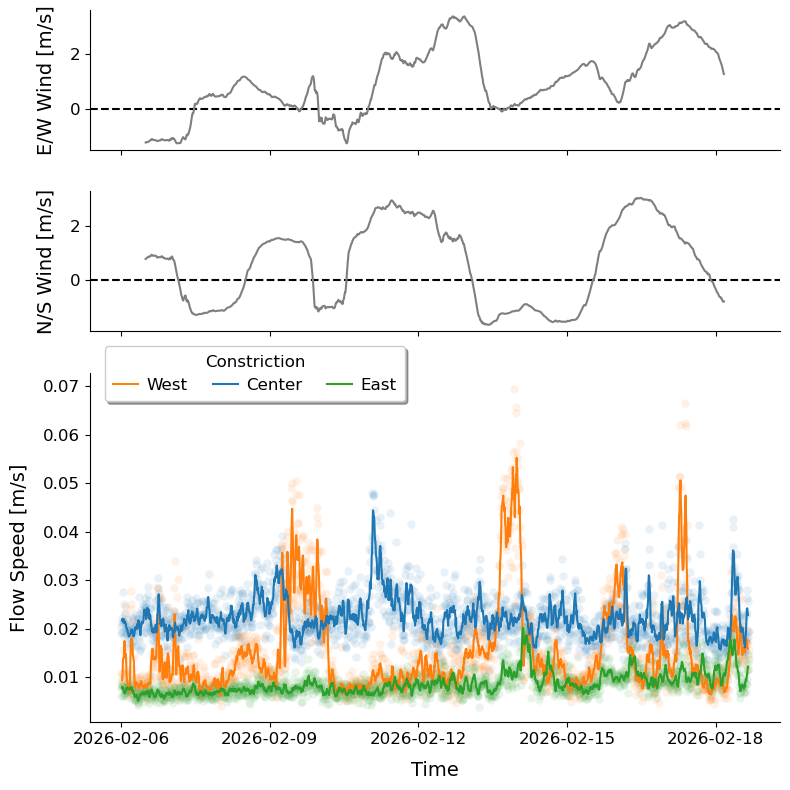

In [304]:
fig, ax = plt.subplots(nrows=3, figsize=(8, 8), sharex=True, height_ratios=[1, 1, 2.5])

# E/W wind projection
ax[0].axhline(0, color='black', linestyle='--')
sns.lineplot(x=u_wind_ra.sel(time=slice(t_start, t_end)).time, y=u_wind_ra.sel(time=slice(t_start, t_end)), color='tab:gray', ax=ax[0])

# N/S wind projection
ax[1].axhline(0, color='black', linestyle='--')
sns.lineplot(x=v_wind_ra.sel(time=slice(t_start, t_end)).time, y=v_wind_ra.sel(time=slice(t_start, t_end)), color='tab:gray', ax=ax[1])

# flow speed
sns.scatterplot(x=speed_w.time, y=speed_w, alpha=0.1, color='tab:orange', ax=ax[2])
sns.scatterplot(x=speed_c.time, y=speed_c, alpha=0.1, color='tab:blue', ax=ax[2])
sns.scatterplot(x=speed_e.time, y=speed_e, alpha=0.1, color='tab:green', ax=ax[2])

sns.lineplot(x=sw_ra.time, y=sw_ra, label='West', color='tab:orange', ax=ax[2])
sns.lineplot(x=sc_ra.time, y=sc_ra, label='Center', color='tab:blue', ax=ax[2])
sns.lineplot(x=se_ra.time, y=se_ra, label='East', color='tab:green', ax=ax[2])

ax[0].set_ylabel('E/W Wind [m/s]', fontsize=14, labelpad=10)
ax[1].set_ylabel('N/S Wind [m/s]', fontsize=14, labelpad=10)

ax[2].set_xlabel('Time', fontsize=14, labelpad=10)
ax[2].set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax[2].xaxis.set_major_locator(mdates.DayLocator(interval=3))

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)

ax[2].legend(ncols=3, title='Constriction', fontsize=12, title_fontsize=12, shadow=True, fancybox=True, loc='upper left', bbox_to_anchor=(0.01, 1.1),
          handlelength=1.5, handletextpad=0.5, columnspacing=1.5, borderpad=0.5)

plt.tight_layout()
plt.show()

### Observational data

In [3]:
# local ewgreaders imports
from readers.ctd_reader import CTDReader
from readers.mooring_reader import MooringReader
from readers.adcp_reader import ADCPReader
from readers.thermistor_reader import ThermistorReader
from readers.o2_reader import O2Reader
from data_index import get_data_index
import datsci.efd as efd
import datsci.lakes as lakes
import datsci.signal as signal

In [4]:
lake = 'Zug'

In [5]:
di_ctd = get_data_index(lake, 'ctd')
di_ctd

,lake,date,time,profile_loc,xsc,ysc,sensor,serial_id,fname
0,Zug,2024-11-08,10:42,P9,680173,217479,sea&sun,1807,IB081320_2
1,Zug,2024-11-08,11:02,P7,680083,218327,sea&sun,1807,IB081320_3
2,Zug,2024-11-08,11:20,P6W,679942,218820,sea&sun,1807,IB081320_4
3,Zug,2024-11-08,11:34,P6,680090,218816,sea&sun,1807,IB081320_5
4,Zug,2024-11-08,11:52,P5'',679841,219294,sea&sun,1807,IB081320_6
...,...,...,...,...,...,...,...,...,...
283,Zug,2026-04-09,14:31,P6W,679931,218791,sea&sun,2023,K4101445_6
284,Zug,2026-04-09,14:54,P10,680813,216240,sea&sun,2023,K4101445_7
285,Zug,2026-04-10,10:19,P6E,680288,218845,sea&sun,2023,K4101445_8
286,Zug,2026-04-10,11:14,P6W,679912,218786,sea&sun,2023,K4101445_9


In [5]:
di_m = get_data_index(lake, 'mooring')
di_m

,lake,date,location,xsc,ysc,deploy,retrieve,sensor,serial_id,depth
0,Zug,2024-04-24,LZC,680101,218799,2024-01-04,2024-04-24,rbr_temp,205515,130.9
1,Zug,2024-04-24,LZC,680101,218799,2024-01-04,2024-04-24,adcp,16576,137.3
2,Zug,2024-04-24,LZC,680101,218799,2024-01-04,2024-04-24,adcp,24399,137.3
3,Zug,2024-04-24,LZC,680101,218799,2024-01-04,2024-04-24,rbr_duet,82133,137.3
4,Zug,2024-04-24,LZC,680101,218799,2024-01-04,2024-04-24,rbr_temp,209292,140.9
...,...,...,...,...,...,...,...,...,...,...
321,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,minidot,117137,133.4
322,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,rbr_temp,205513,133.4
323,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,minidot,587731,138.8
324,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,rbr_temp,209301,138.8


In [10]:
# load CTD profile
date = '2026-01-13'
pl = 'VMPC'
di_ctd_sel = di_ctd.query("date == @date and profile_loc == @pl")
display(di_ctd_sel)

p = di_ctd_sel.iloc[0]    # select 1 profile

C:\Users\herremha\AppData\Local\Temp\ipykernel_16288\2940512707.py:4: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_ctd_sel = di_ctd.query("date == @date and profile_loc == @pl")


,lake,date,time,profile_loc,xsc,ysc,sensor,serial_id,fname
191,Zug,2026-01-13,12:15,VMPC,680120,218743,sea&sun,1807,K1131806_2
192,Zug,2026-01-13,13:37,VMPC,680107,218629,sea&sun,1807,K1131806_3
195,Zug,2026-01-13,16:23,VMPC,680144,218638,sea&sun,1807,K1131806_6


In [11]:
# instantiate CTDReader object
ctdreader = CTDReader(p.lake, p.date, p.fname)

# load processed data
ds_ctd = ctdreader.load()
ds_ctd

<xarray.Dataset> Size: 632kB
Dimensions:     (depth: 4646)
Coordinates:
    time        (depth) datetime64[ns] 37kB 2026-01-13T11:15:30.692000 ... 20...
  * depth       (depth) float64 37kB 0.5334 0.5513 0.5835 ... 143.6 143.6 143.6
Data variables: (12/15)
    press       (depth) float64 37kB 0.2183 0.2359 0.2675 ... 140.6 140.6 140.6
    temp        (depth) float64 37kB 5.934 5.933 5.934 ... 5.455 5.454 5.454
    cond        (depth) float64 37kB 0.178 0.178 0.178 ... 0.1888 0.1888 0.1876
    cond25      (depth) float64 37kB 0.2877 0.2877 0.2877 ... 0.3099 0.308
    turb        (depth) float64 37kB 0.0 0.0 0.58 0.28 ... 0.4 0.43 0.43 0.43
    do2_sat     (depth) float64 37kB 77.54 76.75 76.7 76.53 ... 0.49 0.5 0.5
    ...          ...
    salin       (depth) float64 37kB 0.2458 0.2458 0.2458 ... 0.2641 0.2624
    cond20      (depth) float64 37kB 281.2 281.2 281.2 ... 302.2 302.2 300.3
    rho         (depth) float64 37kB 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
    ptemp       (depth) float64 37kB 5.934 5.933 5.934 ... 5.452 5.452 5.452
    prho        (depth) float64 37kB 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
    fall_speed  (depth) float64 37kB 0.1246 0.1869 0.2373 ... 0.2295 0.3011
Attributes: (12/22)
    project:        IBEX
    captain:        Haydn Herrema
    crew:           Tomy Doda
    lake:           Zug
    altitude:       417
    date:           2026-01-13
    ...             ...
    wind_strength:  
    drift:          N
    boat_moving:    True
    stop:           []
    bottom:         False
    comments:       winch slow; move boat at 115 m

In [8]:
# 1-meter rolling average on CTD density profile
rho = ds_ctd['rho']
rho_ra = signal.rolling_average_z(rho)

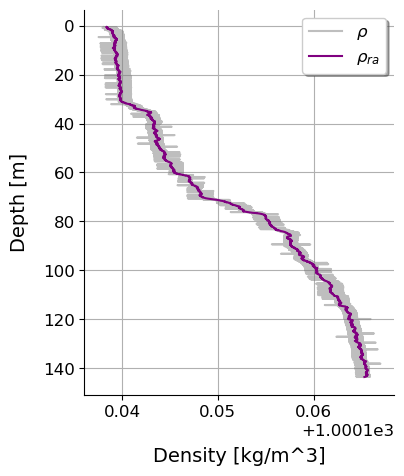

In [9]:
fig, ax = plt.subplots(figsize=(4, 5))

sns.lineplot(x=rho, y=rho.depth, orient='y', color='tab:gray', alpha=0.5, ax=ax, label=r'$\rho$')
sns.lineplot(x=rho_ra, y=rho_ra.depth, orient='y', color='purple', ax=ax, label=r'$\rho_{ra}$')

ax.set_xlabel('Density [kg/m^3]', fontsize=14, labelpad=20)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

ax.invert_yaxis()
ax.legend(fontsize=12, shadow=True)

plt.show()